# Notebook 06 — MLflow Model Experiments

**Goal:** Rigorously compare feature lag representations (1-lag, 2-lag, 4-lag, and 12-lag) across baseline and non-linear machine learning models under strict chronological evaluation tracked with MLflow.

### Models Evaluated:
1. **Historical Mean Baseline (Dummy)**
2. **ElasticNet Regressor**
3. **Random Forest Regressor**
4. **XGBoost Regressor**
5. **LightGBM Regressor**

### Tracking:
All experiments, hyper-parameters, validation/test metrics (MAE, RMSE, R2, Outbreak MAE) are tracked in MLflow.


### 1. Imports & Environment Setup


In [1]:
from __future__ import annotations

import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import mlflow
import mlflow.sklearn


/media/breezy/NewVolume/projects_int/dengue/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Configuration & MLflow Setup


In [2]:
DATA_DIR = Path("../data/processed")
MLFLOW_TRACKING_URI = "../mlruns"
EXPERIMENT_NAME = "dengue_baseline_experiments"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Active Experiment: {EXPERIMENT_NAME}")


MLflow Tracking URI: ../mlruns
Active Experiment: dengue_baseline_experiments


### 3. Load Processed Datasets


In [3]:
datasets = {
    "1-Lag": pd.read_parquet(DATA_DIR / "dengue_features_1lags.parquet"),
    "2-Lag": pd.read_parquet(DATA_DIR / "dengue_features_2lags.parquet"),
    "4-Lag": pd.read_parquet(DATA_DIR / "dengue_features_4lags.parquet"),
    "12-Lag": pd.read_parquet(DATA_DIR / "dengue_features_12lags.parquet"),
}

for name, df_temp in datasets.items():
    df_temp["week_start"] = pd.to_datetime(df_temp["week_start"])
    df_temp.sort_values(["district", "week_start"], inplace=True)
    print(f"{name:8s} | Shape: {df_temp.shape} | Date Range: {df_temp['week_start'].min().date()} to {df_temp['week_start'].max().date()}")


1-Lag    | Shape: (26338, 20) | Date Range: 2007-01-08 to 2026-06-29
2-Lag    | Shape: (26286, 25) | Date Range: 2007-01-15 to 2026-06-29
4-Lag    | Shape: (26182, 30) | Date Range: 2007-01-29 to 2026-06-29
12-Lag   | Shape: (25766, 34) | Date Range: 2007-03-26 to 2026-06-29


### 4. Time-Aware Chronological Train / Val / Test Split


In [4]:
# Split boundaries
TRAIN_END = pd.Timestamp("2020-12-31")
VAL_END = pd.Timestamp("2023-12-31")

def get_splits(df_input):
    feature_cols = [c for c in df_input.columns if c not in ["district", "week_start", "cases"]]
    train_mask = df_input["week_start"] <= TRAIN_END
    val_mask = (df_input["week_start"] > TRAIN_END) & (df_input["week_start"] <= VAL_END)
    test_mask = df_input["week_start"] > VAL_END
    
    X_tr, y_tr = df_input.loc[train_mask, feature_cols], df_input.loc[train_mask, "cases"]
    X_va, y_va = df_input.loc[val_mask, feature_cols], df_input.loc[val_mask, "cases"]
    X_te, y_te = df_input.loc[test_mask, feature_cols], df_input.loc[test_mask, "cases"]
    return X_tr, y_tr, X_va, y_va, X_te, y_te, feature_cols

print(f"Train period: <= {TRAIN_END.date()}")
print(f"Val period:   {TRAIN_END.date()} to {VAL_END.date()}")
print(f"Test period:  > {VAL_END.date()}")


Train period: <= 2020-12-31
Val period:   2020-12-31 to 2023-12-31
Test period:  > 2023-12-31


### 5. Evaluation Metrics & Outbreak Assessment Helper


In [5]:
def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Outbreak MAE (top 5% highest case counts)
    outbreak_threshold = np.quantile(y_true, 0.95)
    outbreak_mask = y_true >= outbreak_threshold
    outbreak_mae = mean_absolute_error(y_true[outbreak_mask], y_pred[outbreak_mask]) if outbreak_mask.sum() > 0 else np.nan
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Outbreak_MAE": outbreak_mae}


### 6. Model Training & MLflow Experiment Loop


In [6]:
results_list = []

for dataset_name, df_data in datasets.items():
    X_train, y_train, X_val, y_val, X_test, y_test, features = get_splits(df_data)
    
    candidate_models = {
        "Historical_Mean": DummyRegressor(strategy="mean"),
        "ElasticNet": ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1),
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.08, random_state=42, n_jobs=-1),
        "LightGBM": lgb.LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.08, random_state=42, verbose=-1, n_jobs=-1),
    }
    
    for model_name, model in candidate_models.items():
        run_name = f"{model_name}_{dataset_name}"
        with mlflow.start_run(run_name=run_name):
            # Log parameters
            mlflow.log_param("dataset", dataset_name)
            mlflow.log_param("model_type", model_name)
            mlflow.log_param("num_features", len(features))
            
            # Fit model
            model.fit(X_train, y_train)
            
            # Validate
            val_preds = np.maximum(0, model.predict(X_val))
            val_metrics = evaluate_predictions(y_val, val_preds)
            
            # Test
            test_preds = np.maximum(0, model.predict(X_test))
            test_metrics = evaluate_predictions(y_test, test_preds)
            
            # Log metrics to MLflow
            mlflow.log_metrics({
                "val_mae": val_metrics["MAE"],
                "val_rmse": val_metrics["RMSE"],
                "val_r2": val_metrics["R2"],
                "val_outbreak_mae": val_metrics["Outbreak_MAE"],
                "test_mae": test_metrics["MAE"],
                "test_rmse": test_metrics["RMSE"],
                "test_r2": test_metrics["R2"],
                "test_outbreak_mae": test_metrics["Outbreak_MAE"],
            })
            
            results_list.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Val_MAE": val_metrics["MAE"],
                "Val_RMSE": val_metrics["RMSE"],
                "Val_R2": val_metrics["R2"],
                "Test_MAE": test_metrics["MAE"],
                "Test_RMSE": test_metrics["RMSE"],
                "Test_R2": test_metrics["R2"],
                "Test_Outbreak_MAE": test_metrics["Outbreak_MAE"],
            })

results_df = pd.DataFrame(results_list).sort_values("Val_MAE")
print("=== Baseline Model Comparison Table ===")
print(results_df.to_string(index=False))


/media/breezy/NewVolume/projects_int/dengue/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.078864e+06, tolerance: 1.391e+04
  model = cd_fast.enet_coordinate_descent(
/media/breezy/NewVolume/projects_int/dengue/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.994075e+06, tolerance: 1.389e+04
  model = cd_fast.enet_coordinate_descent(


=== Baseline Model Comparison Table ===
Dataset           Model   Val_MAE  Val_RMSE    Val_R2  Test_MAE  Test_RMSE   Test_R2  Test_Outbreak_MAE
  2-Lag      ElasticNet 15.472737 50.516348  0.336186 14.257640  49.313056  0.666380          87.351943
  1-Lag      ElasticNet 15.667435 52.054247  0.291267 14.493571  50.923930  0.644228          87.355327
  1-Lag        LightGBM 15.744838 51.712694  0.300537 14.834149  52.303868  0.624686          88.012960
  2-Lag        LightGBM 15.772747 50.285481  0.342240 14.206814  48.303296  0.679903          85.118640
  2-Lag         XGBoost 15.817315 49.364484  0.366113 14.436781  49.466016  0.664308          90.548347
  1-Lag         XGBoost 15.901998 50.864993  0.323281 15.399183  52.909593  0.615942          98.736168
  1-Lag    RandomForest 16.009544 52.042522  0.291587 15.299671  52.816971  0.617286          92.993879
  4-Lag        LightGBM 16.154452 49.856833  0.360246 13.880581  46.703365  0.700757          86.017663
  2-Lag    RandomForest 

### 7. Visual Model Comparison & Error Analysis


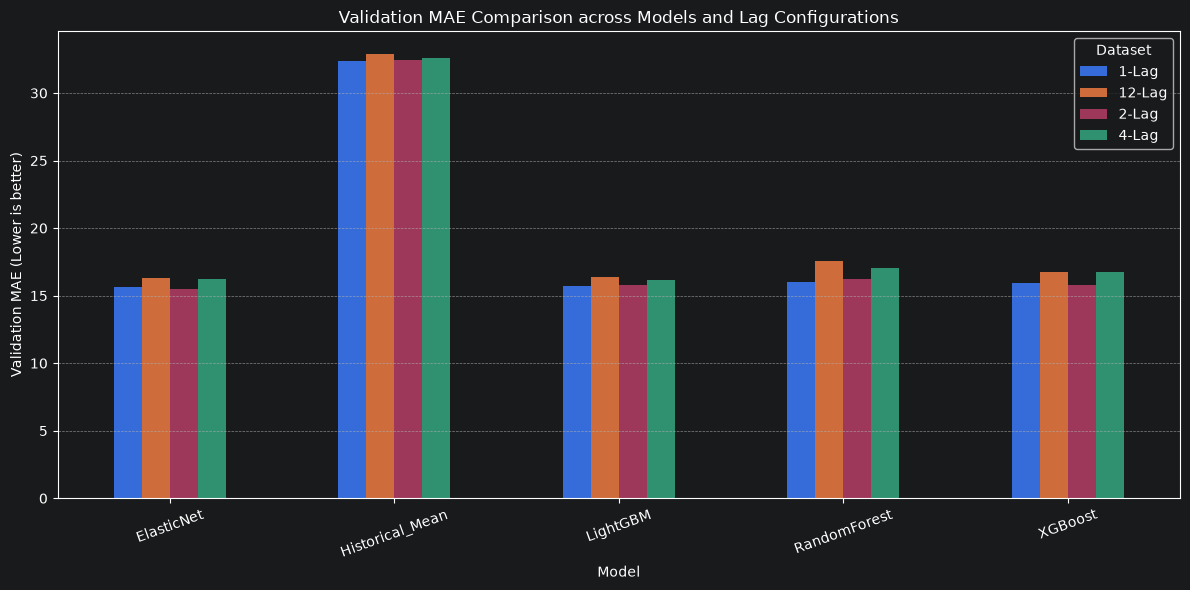

In [7]:
pivot_val = results_df.pivot(index="Model", columns="Dataset", values="Val_MAE")
pivot_val.plot(kind="bar", figsize=(12, 6))
plt.title("Validation MAE Comparison across Models and Lag Configurations")
plt.ylabel("Validation MAE (Lower is better)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### 8. Key Findings & Baseline Conclusions


In [8]:
best_model = results_df.iloc[0]
print(f"Best Configuration: {best_model['Model']} on {best_model['Dataset']}")
print(f"Validation MAE: {best_model['Val_MAE']:.3f} | Test MAE: {best_model['Test_MAE']:.3f}")


Best Configuration: ElasticNet on 2-Lag
Validation MAE: 15.473 | Test MAE: 14.258
